# 00. Аудит сырых данных

Цель: понять структуру датасета до препроцессинга.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_cwd = Path.cwd().resolve()
REPO_ROOT = _cwd if (_cwd / "data").is_dir() else _cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config import RAW_DIR

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", "{:,.2f}".format)


def _col(df, *candidates):
    """Первая колонка из candidates, которая есть в df. Иначе None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

import matplotlib as mpl

C1, C2, C3 = "#2C7BB6", "#D7542B", "#2D9E5F"
PALETTE     = (C1, C2, C3, "#7B4F9E", "#E8B84B", "#5BB8C7",
               "#937860", "#DA8BC3", "#8C8C8C", "#CCB974")

plt.rcParams.update({
    "figure.figsize":    (10, 5),
    "figure.dpi":        150,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "legend.framealpha": 0.8,
    "legend.edgecolor":  "0.8",
    "axes.spines.right": False,
    "axes.spines.top":   False,
    "axes.grid":         True,
    "axes.grid.axis":    "both",
    "grid.alpha":        0.3,
    "grid.linewidth":    0.5,
    "lines.linewidth":   1.8,
    "lines.markersize":  5,
    "axes.prop_cycle":   mpl.cycler("color", list(PALETTE)),
})

FIG_DIR = REPO_ROOT / "reports" / "figures" / "00_data_audit"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
PRICE_FILES = {
    "2020_2025":  "price_dataflat_2020_2025.csv",
    "2023_01_06": "price_dataflat_2023_01_06.csv",
    "2023_04_12": "price_dataflat_2023_04_12.csv",
    "2023_07_12": "price_dataflat_2023_07_12.csv",
    "2024_01_06": "price_dataflat_2024_01_06.csv",
    "2024_07_12": "price_dataflat_2024_07_12.csv",
    "2025_01_05": "price_dataflat_2025_01_05.csv",
}

price_parts = []
for label, fname in PRICE_FILES.items():
    path = RAW_DIR / fname
    if not path.is_file():
        print(f"skip (нет): {fname}")
        continue
    df = pd.read_csv(path, low_memory=False)
    df["price_slice"] = label
    price_parts.append(df)

price_all = pd.concat(price_parts, ignore_index=True)
deals = pd.read_csv(RAW_DIR / "deals_dataflat_2020_2025.csv", low_memory=False)

print(f"price_all : {price_all.shape[0]:>10,} строк, {price_all.shape[1]} колонок")
print(f"deals     : {deals.shape[0]:>10,} строк, {deals.shape[1]} колонок")

price_all :  5,106,109 строк, 41 колонок
deals     :    772,999 строк, 53 колонок


## 1. Инвентаризация файлов в `data/raw/`

In [3]:
csv_files = sorted(RAW_DIR.glob("*.csv"))
print(f"CSV-файлов в data/raw/: {len(csv_files)}\n")
for f in csv_files:
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:50s}  {size_mb:7.1f} МБ")

CSV-файлов в data/raw/: 8

  deals_dataflat_2020_2025.csv                          663.7 МБ
  price_dataflat_2020_2025.csv                          433.8 МБ
  price_dataflat_2023_01_06.csv                         280.4 МБ
  price_dataflat_2023_04_12.csv                         334.8 МБ
  price_dataflat_2023_07_12.csv                         265.5 МБ
  price_dataflat_2024_01_06.csv                         278.9 МБ
  price_dataflat_2024_07_12.csv                         282.0 МБ
  price_dataflat_2025_01_05.csv                         234.3 МБ


## 2. Прайс: per-slice статистика

Каждый файл: строки, даты, begin/end split, null% в ключевых полях.

In [4]:
slice_audit = []
for part in price_parts:
    label = part["price_slice"].iloc[0]
    row = {"slice": label, "rows": len(part), "cols": part.shape[1] - 1}

    fd_col = _col(part, "Дата файла", "file_date")
    if fd_col:
        fd = pd.to_datetime(part[fd_col], dayfirst=True, errors="coerce")
        row["date_min"] = fd.min().date() if fd.notna().any() else None
        row["date_max"] = fd.max().date() if fd.notna().any() else None
        row["months"]   = fd.dt.to_period("M").nunique()

    ms_col = _col(part, "Начало/конец месяца", "month_span")
    if ms_col:
        vc = part[ms_col].value_counts()
        row["begin"] = vc.get("begin", 0)
        row["end"]   = vc.get("end",   0)

    for name, ru, en in [
        ("project_id", "ID Проекта", "project_id"),
        ("building_id", "ID Корпус", "building_id"),
        ("area",        "Площадь",   "area"),
        ("price",       "Цена",      "price"),
    ]:
        col = _col(part, ru, en)
        row[f"{name}_null%"] = round(100 * part[col].isna().mean(), 1) if col else None

    slice_audit.append(row)

display(pd.DataFrame(slice_audit))

,slice,rows,cols,date_min,date_max,months,begin,end,project_id_null%,building_id_null%,area_null%,price_null%
0,2020_2025,1048565,40,2021-01-01,2022-04-04,16,982543,66022,0.00,0.00,0.00,0.00
1,2023_01_06,673906,40,2023-01-10,2023-06-02,6,673906,0,0.00,0.00,0.00,0.00
2,2023_04_12,808788,40,2022-04-04,2022-12-02,9,808788,0,0.00,0.00,0.00,0.00
3,2023_07_12,651869,40,2023-07-04,2023-12-04,6,651869,0,0.00,0.00,0.00,0.00
4,2024_01_06,677061,40,2024-01-09,2024-06-03,6,677061,0,0.00,0.00,0.00,0.00
5,2024_07_12,684203,40,2024-07-02,2024-12-02,6,684203,0,0.00,0.00,0.00,0.00
6,2025_01_05,561717,40,2025-01-02,2025-05-05,5,561717,0,0.00,0.00,0.00,0.00


## 3. Прайс: схема (колонки, типы, null%)

Используем объединённый `price_all`. Сортировка по доле пропусков.

In [5]:
price_schema = pd.DataFrame({
    "dtype":   price_all.dtypes.astype(str),
    "null%":   (price_all.isna().mean() * 100).round(1),
    "nunique": price_all.nunique(),
    "sample":  price_all.iloc[0],
}).sort_values("null%", ascending=False)

print(f"Всего колонок: {len(price_schema)}")
display(price_schema)

Всего колонок: 41


,dtype,null%,nunique,sample
pool,str,0.00,999167,"534@1419@1@108@5@248,2@4"
Цена без скидки,str,0.00,347093,213838
Бюджет без скидки,str,0.00,2154227,53074718
Бюджет,str,0.00,2218716,53074718
"Скидка, %",str,0.00,18,0
Наличие бюджета,str,0.00,2,Да
Изменение цены последнее,object,0.00,736814,0
Дата файла,str,0.00,54,01.01.2021
Начало/конец месяца,str,0.00,2,end
Источник,str,0.00,83452,http://donstroy.com


## 4. Прайс: категориальные распределения

In [6]:
CAT_COLS_PRICE = [
    ("Начало/конец месяца", "month_span"),
    ("Класс проекта",       "project_class"),
    ("Регион",              "region"),
    ("Округ",               "macro_district"),
    ("Район",               "district"),
    ("Девелопер",           "developer"),
    ("Тип помещения",       "premises_type"),
    ("Ключи",               "keys_status"),
    ("Стадия К",            "stage_k"),
    ("Договор К",           "contract_type_k"),
    ("Отделка К",           "finish_tier"),
    ("Отделка в отчет",     "finish_in_report"),
    ("Отделка текст",       "finish_text"),
    ("Тип кв/ап",           "unit_typology"),
    ("Комнатность",         "room_count"),
    ("Секция",              "section"),
    ("Наличие бюджета",     "has_budget"),
    ("Источник",            "source"),
    ("Период",              "period"),
]

for ru, en in CAT_COLS_PRICE:
    col = _col(price_all, ru, en)
    if col is None:
        print(f"  нет колонки: {ru} / {en}")
        continue
    vc = price_all[col].value_counts(dropna=False)
    total = len(price_all)
    print(f"\n{'─'*55}")
    print(f"  {col}  ({vc.shape[0]} уникальных)")
    print(f"{'─'*55}")
    for val, cnt in vc.head(20).items():
        bar = '█' * int(30 * cnt / total)
        print(f"  {str(val):<30s} {cnt:>8,}  {100*cnt/total:5.1f}%  {bar}")


───────────────────────────────────────────────────────
  Начало/конец месяца  (2 уникальных)
───────────────────────────────────────────────────────
  begin                          5,040,087   98.7%  █████████████████████████████
  end                              66,022    1.3%  

───────────────────────────────────────────────────────
  Класс проекта  (4 уникальных)
───────────────────────────────────────────────────────
  комфорт                        3,967,153   77.7%  ███████████████████████
  бизнес                         1,009,877   19.8%  █████
  премиум                          88,470    1.7%  
  де-люкс                          40,609    0.8%  



───────────────────────────────────────────────────────
  Регион  (3 уникальных)
───────────────────────────────────────────────────────
  Москва                         2,319,511   45.4%  █████████████
  Московская область             1,948,718   38.2%  ███████████
  Новая Москва                    837,880   16.4%  ████



───────────────────────────────────────────────────────
  Округ  (59 уникальных)
───────────────────────────────────────────────────────
  НАО                             799,947   15.7%  ████
  ЗАО                             377,540    7.4%  ██
  Ленинский городской округ       337,135    6.6%  █
  ЮАО                             330,881    6.5%  █
  ЮВАО                            312,745    6.1%  █
  САО                             295,602    5.8%  █
  СВАО                            273,977    5.4%  █
  СЗАО                            272,303    5.3%  █
  Одинцово городской округ        188,456    3.7%  █
  Люберцы городской округ         188,260    3.7%  █
  Мытищи городской округ          176,185    3.5%  █
  Красногорск городской округ     163,502    3.2%  
  Балашиха городской округ        157,205    3.1%  
  ЦАО                             149,096    2.9%  
  ВАО                             144,160    2.8%  
  ЮЗАО                            140,112    2.7%  
  Пушкино город


───────────────────────────────────────────────────────
  Тип помещения  (4 уникальных)
───────────────────────────────────────────────────────
  Квартира                       4,639,868   90.9%  ███████████████████████████
  Апартамент                      466,236    9.1%  ██
  Апартаменты                           3    0.0%  
  Пентхаус                              2    0.0%  



───────────────────────────────────────────────────────
  Ключи  (96 уникальных)
───────────────────────────────────────────────────────
  2Q 25                           367,277    7.2%  ██
  1Q 26                           353,906    6.9%  ██
  2Q 26                           338,336    6.6%  █
  4Q 24                           314,131    6.2%  █
  -                               287,671    5.6%  █
  4Q 23                           266,678    5.2%  █
  4Q 25                           256,229    5.0%  █
  3Q 24                           252,102    4.9%  █
  2Q 24                           235,580    4.6%  █
  1Q 24                           207,376    4.1%  █
  1Q 25                           204,896    4.0%  █
  3Q 25                           183,223    3.6%  █
  2Q 27                           174,611    3.4%  █
  2Q 23                           171,520    3.4%  █
  4Q 26                           169,841    3.3%  
  4Q 27                           165,946    3.2%  
  3Q 26       


───────────────────────────────────────────────────────
  Отделка в отчет  (9 уникальных)
───────────────────────────────────────────────────────
  б/о                            2,438,271   47.8%  ██████████████
  с/о                            1,708,099   33.5%  ██████████
  wb                              649,112   12.7%  ███
  Н/Д                             269,963    5.3%  █
  с/о + кух                        35,005    0.7%  
  б/о и wb                          2,103    0.0%  
  б/о и с/о                         1,814    0.0%  
  wb и с/о                          1,545    0.0%  
  wb и с/о + кух                      197    0.0%  



───────────────────────────────────────────────────────
  Отделка текст  (202 уникальных)
───────────────────────────────────────────────────────
  -                              2,660,698   52.1%  ███████████████
  Без отделки                     772,197   15.1%  ████
  С отделкой                      355,996    7.0%  ██
  готовая                         212,777    4.2%  █
  готовая отделка                 106,204    2.1%  
  нет                             100,271    2.0%  
  white box                        78,389    1.5%  
  White-box, Дизайнерская          72,286    1.4%  
  Дизайнерская                     66,854    1.3%  
  1                                66,812    1.3%  
  Чистовая отделка                 58,002    1.1%  
  Чистовая                         52,030    1.0%  
  mr base                          49,391    1.0%  
  whitebox                         47,132    0.9%  
  предчистовая                     46,472    0.9%  
  Отделка White box                39,737    0.8% 


───────────────────────────────────────────────────────
  Наличие бюджета  (2 уникальных)
───────────────────────────────────────────────────────
  Да                             5,086,429   99.6%  █████████████████████████████
  Нет                              19,680    0.4%  



───────────────────────────────────────────────────────
  Источник  (83452 уникальных)
───────────────────────────────────────────────────────
  http://pik.ru                   709,633   13.9%  ████
  https://samoletgroup.ru         500,127    9.8%  ██
  https://a101.ru                 382,884    7.5%  ██
  https://www.lsr.ru              128,217    2.5%  
  https://www.granelle.ru         108,434    2.1%  
  https://fsk.ru                   96,859    1.9%  
  http://www.dsk1.ru               85,622    1.7%  
  https://www.absrealty.ru         83,017    1.6%  
  https://www.gk-mic.ru            71,799    1.4%  
  https://vatutinki.ru             61,583    1.2%  
  http://donstroy.com              58,898    1.2%  
  https://msk.sevensuns.ru         54,853    1.1%  
  https://www.mr-group.ru          52,800    1.0%  
  https://www.ndv.ru               51,732    1.0%  
  https://www.ingrad.ru            47,585    0.9%  
  https://gk-osnova.ru             40,043    0.8%  
  https://profi-

## 5. Прайс: числовые распределения

In [7]:
NUM_COLS_PRICE = [
    ("Площадь",                   "area"),
    ("Цена",                      "price"),
    ("Цена без скидки",           "price_list"),
    ("Бюджет",                    "budget"),
    ("Бюджет без скидки",         "budget_list"),
    ("Старый бюджет",             "budget_old"),
    ("Скидка, %",                 "discount_pct"),
    ("Изменение цены последнее",  "last_price_change"),
    ("Этаж",                      "floor"),
    ("Экспозиция",                "exposure"),
]

for ru, en in NUM_COLS_PRICE:
    col = _col(price_all, ru, en)
    if col is None:
        print(f"  нет колонки: {ru} / {en}")
        continue
    raw_series = price_all[col]
    num_series = pd.to_numeric(raw_series, errors="coerce")
    n_orig_null   = raw_series.isna().sum()
    n_coerce_null = num_series.isna().sum()
    n_nonnumeric  = n_coerce_null - n_orig_null

    print(f"\n{'─'*55}")
    print(f"  {col}")
    print(f"{'─'*55}")
    print(num_series.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_string())
    if n_nonnumeric > 0:
        nonnumeric_vals = raw_series[num_series.isna() & raw_series.notna()].value_counts().head(10)
        print(f"  Нечисловых значений: {n_nonnumeric:,}")
        print(f"  Примеры: {nonnumeric_vals.to_dict()}")


───────────────────────────────────────────────────────
  Площадь
───────────────────────────────────────────────────────
count   5,106,006.00
mean           52.70
std            28.57
min             2.20
1%             19.80
5%             22.60
25%            35.20
50%            46.30
75%            63.90
95%            98.00
99%           150.50
max         1,852.60


  Нечисловых значений: 103
  Примеры: {'-': 102, 'сх': 1}



───────────────────────────────────────────────────────
  Цена
───────────────────────────────────────────────────────
count    5,086,370.00
mean       308,105.61
std        242,473.41
min         11,974.00
1%          88,612.00
5%         125,062.00
25%        186,606.00
50%        255,312.00
75%        364,876.00
95%        596,362.00
99%      1,151,388.00
max     24,957,898.00
  Нечисловых значений: 19,739
  Примеры: {'-': 19739}



───────────────────────────────────────────────────────
  Цена без скидки
───────────────────────────────────────────────────────
count    5,086,369.00
mean       320,444.44
std        247,593.74
min         11,974.00
1%          88,612.00
5%         125,100.00
25%        191,434.00
50%        264,808.00
75%        385,024.00
95%        629,430.00
99%      1,162,548.00
max     24,957,898.00
  Нечисловых значений: 19,740
  Примеры: {'-': 19740}



───────────────────────────────────────────────────────
  Бюджет
───────────────────────────────────────────────────────
count       5,086,469.00
mean       18,894,498.00
std        49,341,565.14
min           229,350.00
1%          3,717,218.00
5%          4,953,526.00
25%         7,652,156.00
50%        11,060,224.00
75%        18,096,006.00
95%        44,883,810.00
99%       142,759,950.00
max     7,182,929,250.00
  Нечисловых значений: 19,640
  Примеры: {'-': 19640}


...


───────────────────────────────────────────────────────
  Изменение цены последнее
───────────────────────────────────────────────────────
count      4,794,031.00
mean          76,541.15
std        1,304,579.63
min     -401,146,050.00
1%        -1,021,417.00
5%           -92,160.00
25%                0.00
50%                0.00
75%           10,030.00
95%          516,018.00
99%        1,893,432.00
max      718,256,000.00


  Нечисловых значений: 312,078
  Примеры: {'-': 312078}



───────────────────────────────────────────────────────
  Этаж
───────────────────────────────────────────────────────
count   5,101,528.00
mean           11.62
std             8.56
min            -2.00
1%              1.00
5%              2.00
25%             5.00
50%            10.00
75%            16.00
95%            28.00
99%            40.00
max            94.00
  Нечисловых значений: 4,581
  Примеры: {'-': 4110, '19-19А': 172, '2-3': 112, 'P1': 64, 'P2': 51, '1A': 31, '1,2,3': 22, '1 - 2': 8, '\xa0': 6, '19А': 4}



───────────────────────────────────────────────────────
  Экспозиция
───────────────────────────────────────────────────────
count   4,515,388.00
mean          179.23
std           249.34
min             0.00
1%              0.00
5%              0.00
25%            28.00
50%           103.00
75%           242.00
95%           609.00
99%         1,200.00
max         8,271.00


  Нечисловых значений: 590,721
  Примеры: {'-': 590721}


## 6. Сделки: базовая статистика

In [8]:
print(f"Сделки: {deals.shape[0]:,} строк, {deals.shape[1]} колонок")

# Дата регистрации
rd_col = _col(deals, "Дата регистрации_", "registration_date_raw")
if rd_col:
    rd = pd.to_datetime(deals[rd_col], dayfirst=True, errors="coerce")
    print(f"\nregistration_date_raw:  min={rd.min().date()}, max={rd.max().date()}, null={rd.isna().mean():.1%}")

# Уникальные проекты и корпуса
for ru, en in [("ID Проекта", "project_id"), ("ID Корпус", "building_id")]:
    col = _col(deals, ru, en)
    if col:
        print(f"{en}: {deals[col].nunique():,} уникальных")

# Дубли по deal_row_key
key_col = _col(deals, "key", "deal_row_key")
if key_col:
    n_dup = deals.duplicated(key_col).sum()
    print(f"\nДублей по {key_col!r}: {n_dup:,} ({100*n_dup/len(deals):.2f}%)")

print(f"\nПервые 5 колонок: {list(deals.columns[:5])}")
print(f"Последние 5 колонок: {list(deals.columns[-5:])}")

Сделки: 772,999 строк, 53 колонок

registration_date_raw:  min=2020-01-16, max=2025-05-31, null=0.0%
project_id: 923 уникальных
building_id: 4,592 уникальных

Дублей по 'key': 0 (0.00%)

Первые 5 колонок: ['key', 'lat', 'lng', 'ID Проекта', 'ID Проекта для окруженияSales']
Последние 5 колонок: ['Дата регистрации модель', 'Цена кв. м', 'ID дом.рф', 'Бюджет по ПД', 'Цена по ПД']


## 7. Сделки: схема (колонки, типы, null%)

In [9]:
deals_schema = pd.DataFrame({
    "dtype":   deals.dtypes.astype(str),
    "null%":   (deals.isna().mean() * 100).round(1),
    "nunique": deals.nunique(),
    "sample":  deals.iloc[0],
}).sort_values("null%", ascending=False)

print(f"Всего колонок: {len(deals_schema)}")
display(deals_schema)

Всего колонок: 53


,dtype,null%,nunique,sample
key,int64,0.00,772999,40881
Номер регистрации,str,0.00,750975,77:08:0010011:7102-77/060/2022-1406
Дата регистрации_,str,0.00,1695,21.03.2022
Залогодержатель/Банк,str,0.00,24,Сбер
Длительность обременения,str,0.00,388,120
Тип обременения,str,0.00,5,ипотека
Отделка,str,0.00,4,Нет
Дата подписания,str,0.00,65,01.03.2022
Дата ДДУ,str,0.00,1975,15.03.2022
Срок сдачи,str,0.00,57,01.06.2022


## 8. Сделки: категориальные распределения

In [10]:
CAT_COLS_DEALS = [
    ("Класс проекта",                  "project_class"),
    ("Регион",                         "region"),
    ("Округ",                          "macro_district"),
    ("Округ Направление",              "macro_district_direction"),
    ("Район",                          "district"),
    ("Девелопер",                      "developer"),
    ("Тип помещения",                  "premises_type"),
    ("Ключи",                          "keys_status"),
    ("Комнатность",                    "room_count"),
    ("Тип сделки",                     "deal_type"),
    ("Ипотека",                        "mortgage"),
    ("Тип обременения",                "pledge_type"),
    ("Залогодержатель/Банк",           "pledge_holder_bank"),
    ("Опт",                            "is_wholesale"),
    ("Отделка",                        "finish"),
    ("Стадия строительства",           "construction_stage"),
    ("Стадия строительства в дату ДДУ","construction_stage_at_ddu"),
    ("Наличие бюджета",                "has_budget"),
]

for ru, en in CAT_COLS_DEALS:
    col = _col(deals, ru, en)
    if col is None:
        print(f"  нет колонки: {ru} / {en}")
        continue
    vc = deals[col].value_counts(dropna=False)
    total = len(deals)
    print(f"\n{'─'*55}")
    print(f"  {col}  ({vc.shape[0]} уникальных)")
    print(f"{'─'*55}")
    for val, cnt in vc.head(20).items():
        bar = '█' * int(30 * cnt / total)
        print(f"  {str(val):<30s} {cnt:>8,}  {100*cnt/total:5.1f}%  {bar}")


───────────────────────────────────────────────────────
  Класс проекта  (4 уникальных)
───────────────────────────────────────────────────────
  комфорт                         636,536   82.3%  ████████████████████████
  бизнес                          125,361   16.2%  ████
  премиум                           9,276    1.2%  
  де-люкс                           1,826    0.2%  

───────────────────────────────────────────────────────
  Регион  (3 уникальных)
───────────────────────────────────────────────────────
  Москва                          346,794   44.9%  █████████████
  Московская область              294,915   38.2%  ███████████
  Новая Москва                    131,290   17.0%  █████

───────────────────────────────────────────────────────
  Округ  (53 уникальных)
───────────────────────────────────────────────────────
  НАО                             130,204   16.8%  █████
  ЮВАО                             60,085    7.8%  ██
  ЗАО                              58,471    7.

## 9. Сделки: числовые распределения

In [11]:
NUM_COLS_DEALS = [
    ("Площадь",                  "area"),
    ("Цена",                     "price"),
    ("Цена без скидки",          "price_list"),
    ("Бюджет",                   "budget"),
    ("Бюджет без скидки",        "budget_list"),
    ("Бюджет по ПД",             "budget_pd"),
    ("Цена по ПД",               "price_pd"),
    ("Скидка, %",                "discount_pct"),
    ("Этаж",                     "floor"),
    ("Цена кв. м",               "price_per_sqm"),
    ("Длительность обременения", "pledge_duration_months"),
]

for ru, en in NUM_COLS_DEALS:
    col = _col(deals, ru, en)
    if col is None:
        print(f"  нет колонки: {ru} / {en}")
        continue
    raw_series = deals[col]
    num_series = pd.to_numeric(raw_series, errors="coerce")
    n_orig_null   = raw_series.isna().sum()
    n_coerce_null = num_series.isna().sum()
    n_nonnumeric  = n_coerce_null - n_orig_null

    print(f"\n{'─'*55}")
    print(f"  {col}")
    print(f"{'─'*55}")
    print(num_series.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_string())
    if n_nonnumeric > 0:
        nonnumeric_vals = raw_series[num_series.isna() & raw_series.notna()].value_counts().head(10)
        print(f"  Нечисловых значений: {n_nonnumeric:,}")
        print(f"  Примеры: {nonnumeric_vals.to_dict()}")


───────────────────────────────────────────────────────
  Площадь
───────────────────────────────────────────────────────
count   772,979.00
mean         48.83
std          24.15
min           4.50
1%           19.80
5%           22.00
25%          34.30
50%          43.00
75%          59.90
95%          86.40
99%         118.20
max       5,110.00
  Нечисловых значений: 20
  Примеры: {'-': 20}



───────────────────────────────────────────────────────
  Цена
───────────────────────────────────────────────────────
count     766,683.00
mean      263,084.30
std       158,334.10
min        28,050.00
1%         77,091.84
5%        108,838.00
25%       169,842.00
50%       228,988.00
75%       317,018.00
95%       511,237.80
99%       760,594.00
max     7,584,188.00
  Нечисловых значений: 6,316
  Примеры: {'-': 6316}



───────────────────────────────────────────────────────
  Цена без скидки
───────────────────────────────────────────────────────
count     771,803.00
mean      271,319.20
std       166,664.88
min             0.00
1%         63,580.00
5%        104,280.00
25%       171,080.00
50%       234,780.00
75%       332,440.00
95%       541,840.00
99%       789,239.20
max     7,584,180.00
  Нечисловых значений: 1,196
  Примеры: {'-': 1196}



───────────────────────────────────────────────────────
  Бюджет
───────────────────────────────────────────────────────
count         766,683.00
mean       13,570,446.06
std        22,018,764.28
min           457,480.00
1%          2,870,667.60
5%          4,186,254.00
25%         6,778,890.00
50%         9,710,300.00
75%        14,853,110.00
95%        32,340,572.00
99%        67,012,940.00
max     4,817,475,900.00
  Нечисловых значений: 6,316
  Примеры: {'-': 6316}



───────────────────────────────────────────────────────
  Бюджет без скидки
───────────────────────────────────────────────────────
count         765,567.00
mean       14,031,045.33
std        22,145,388.11
min           457,480.00
1%          2,879,745.20
5%          4,212,000.00
25%         6,930,490.00
50%        10,066,600.00
75%        15,514,640.00
95%        33,784,242.00
99%        67,933,649.20
max     4,817,475,900.00
  Нечисловых значений: 7,432
  Примеры: {'-': 7432}



───────────────────────────────────────────────────────
  Бюджет по ПД
───────────────────────────────────────────────────────
count         577,659.00
mean       13,412,577.31
std        16,376,244.07
min           370,618.00
1%          2,910,086.00
5%          4,058,690.40
25%         6,674,966.00
50%         9,988,578.00
75%        15,392,508.00
95%        32,290,388.80
99%        59,728,426.24
max     1,489,164,422.00
  Нечисловых значений: 195,340
  Примеры: {'-': 195340}



───────────────────────────────────────────────────────
  Цена по ПД
───────────────────────────────────────────────────────
count     577,659.00
mean      262,125.21
std       133,871.95
min        16,836.00
1%         89,570.00
5%        125,238.00
25%       176,656.00
50%       234,122.00
75%       317,172.00
95%       475,348.00
99%       668,898.00
max     3,095,336.00
  Нечисловых значений: 195,340
  Примеры: {'-': 195340}
  нет колонки: Скидка, % / discount_pct



───────────────────────────────────────────────────────
  Этаж
───────────────────────────────────────────────────────
count   772,885.00
mean         10.88
std          10.85
min          -2.00
1%            1.00
5%            2.00
25%           5.00
50%           9.00
75%          15.00
95%          25.00
99%          36.00
max       3,955.00
  Нечисловых значений: 114
  Примеры: {'-': 114}



───────────────────────────────────────────────────────
  Цена кв. м
───────────────────────────────────────────────────────
count     771,803.00
mean      271,319.20
std       166,664.92
min             0.00
1%         63,588.00
5%        104,280.20
25%       171,074.00
50%       234,776.00
75%       332,438.00
95%       541,846.40
99%       789,246.96
max     7,584,188.00
  Нечисловых значений: 1,196
  Примеры: {'-': 1196}



───────────────────────────────────────────────────────
  Длительность обременения
───────────────────────────────────────────────────────
count   468,475.00
mean        290.12
std          82.99
min           1.00
1%           62.00
5%          120.00
25%         240.00
50%         327.00
75%         360.00
95%         362.00
99%         362.00
max         600.00
  Нечисловых значений: 304,524
  Примеры: {'-': 304524}


## 10. Временное покрытие

Прайс — строк по месяцам (begin / end):


Начало/конец месяца,begin,end
_period,,
2021-01,0,66022
2021-02,66614,0
2021-03,63224,0
2021-04,58180,0
2021-05,62739,0
2021-06,63332,0
2021-07,63721,0
2021-08,67487,0
2021-09,74957,0


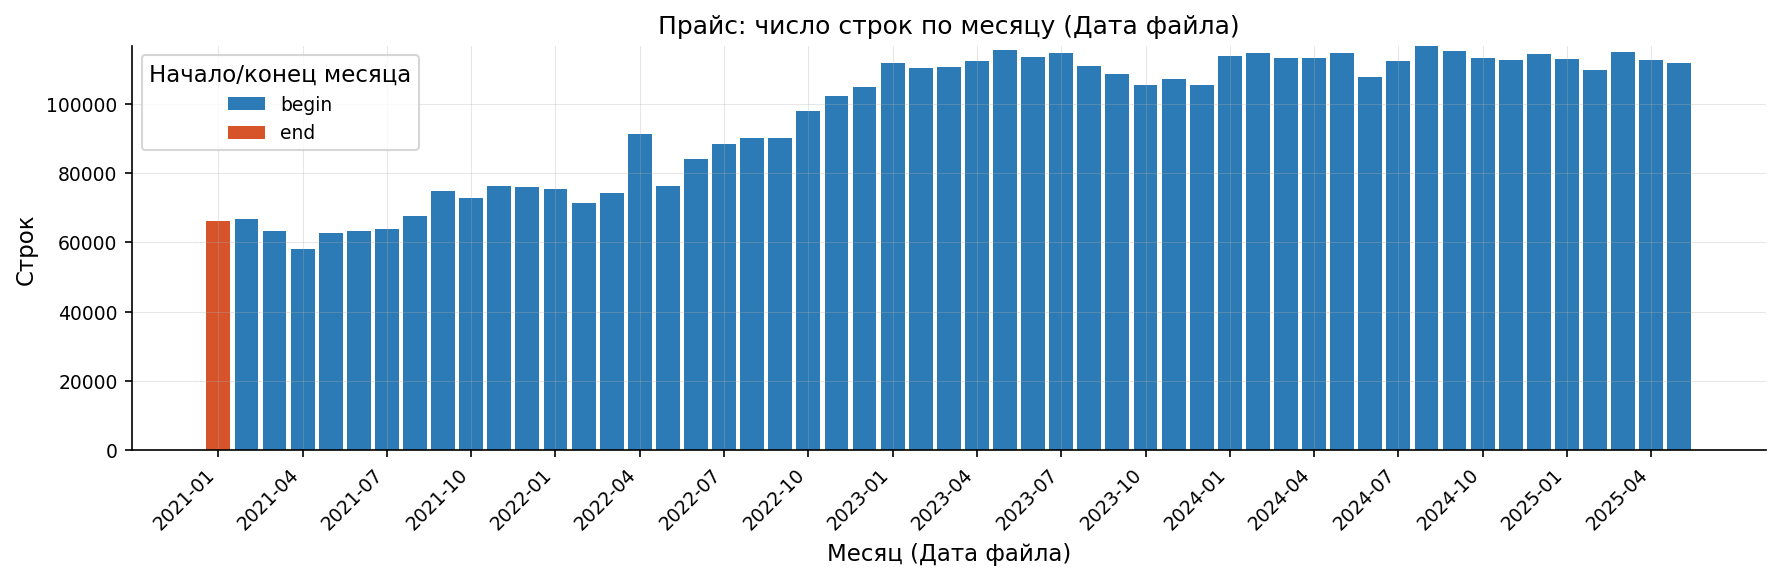


Сделки — по году регистрации:


,deals
Дата регистрации_,
2020,126182
2021,155390
2022,129764
2023,167135
2024,140730
2025,53798



Сделки — по месяцу регистрации:


,deals
Дата регистрации_,
2020-01,2817
2020-02,9285
2020-03,10305
2020-04,7674
2020-05,5159
...,...
2025-01,9712
2025-02,12628
2025-03,11550


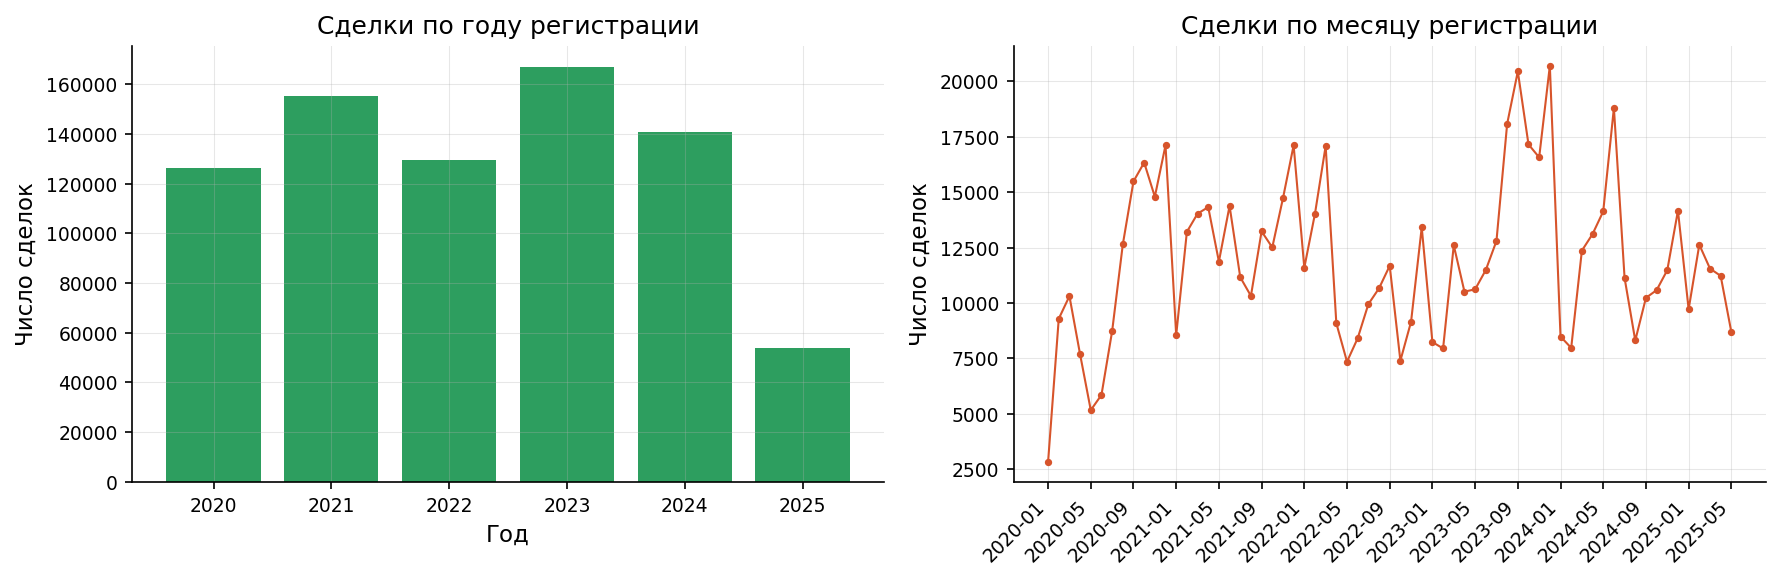

In [12]:
# --- Прайс: строк per file_date (по месяцам) ---
fd_col = _col(price_all, "Дата файла", "file_date")
ms_col = _col(price_all, "Начало/конец месяца", "month_span")


def _sparse_xticks(ax, labels: list[str], max_labels: int = 20) -> None:
    n = len(labels)
    step = max(1, (n + max_labels - 1) // max_labels)
    ticks = list(range(0, n, step))
    ax.set_xticks(ticks)
    ax.set_xticklabels([labels[i] for i in ticks], rotation=45, ha="right")


if fd_col:
    fd = pd.to_datetime(price_all[fd_col], dayfirst=True, errors="coerce")
    price_all["_period"] = fd.dt.to_period("M")

    monthly = (
        price_all.groupby(["_period", ms_col] if ms_col else ["_period"])
        .size()
        .unstack(fill_value=0)
        if ms_col
        else price_all.groupby("_period").size().rename("rows")
    )

    print("Прайс — строк по месяцам (begin / end):")
    display(monthly)

    fig, ax = plt.subplots(figsize=(12, 4))
    # x по np.arange (PeriodIndex-bar иначе смещает тики)
    if isinstance(monthly, pd.DataFrame) and monthly.shape[1] >= 2:
        x = np.arange(len(monthly))
        bottom = np.zeros(len(monthly), dtype=float)
        palette = (
            C1, C2, C3, C2, "#8172B3",
            "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD",
        )
        for i, col in enumerate(monthly.columns):
            vals = monthly[col].to_numpy(dtype=float)
            ax.bar(
                x,
                vals,
                bottom=bottom,
                label=str(col),
                color=palette[i % len(palette)],
                width=0.85,
                edgecolor="none",
            )
            bottom += vals
        ax.legend(loc="upper left", title=ms_col)
        _sparse_xticks(ax, [str(p) for p in monthly.index])
    elif isinstance(monthly, pd.DataFrame):
        c = monthly.columns[0]
        x = np.arange(len(monthly))
        ax.bar(x, monthly[c].values, color=C1, edgecolor="none")
        _sparse_xticks(ax, [str(p) for p in monthly.index])
    else:
        s = monthly
        x = np.arange(len(s))
        ax.bar(x, s.values, color=C1, edgecolor="none")
        _sparse_xticks(ax, [str(p) for p in s.index])
    ax.set_title("Прайс: число строк по месяцу (Дата файла)")
    ax.set_xlabel("Месяц (Дата файла)")
    ax.set_ylabel("Строк")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig01_price_rows_monthly.png", bbox_inches="tight")
    plt.show()

    price_all.drop(columns=["_period"], inplace=True)

# --- Сделки: строк по году регистрации ---
rd_col = _col(deals, "Дата регистрации_", "registration_date_raw")
if rd_col:
    rd = pd.to_datetime(deals[rd_col], dayfirst=True, errors="coerce")
    by_year = rd.dt.year.value_counts().sort_index().rename("deals")
    by_month = rd.dt.to_period("M").value_counts().sort_index().rename("deals")

    print("\nСделки — по году регистрации:")
    display(by_year.to_frame())

    print("\nСделки — по месяцу регистрации:")
    display(by_month.to_frame())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    by_y = by_year[pd.notna(by_year.index)]
    axes[0].bar(by_y.index.astype(int), by_y.values, color=C3, edgecolor="none")
    axes[0].set_title("Сделки по году регистрации")
    axes[0].set_xlabel("Год")
    axes[0].set_ylabel("Число сделок")

    bm = by_month.sort_index()
    bm = bm[pd.notna(bm.index)]
    x = np.arange(len(bm))
    axes[1].plot(x, bm.to_numpy(), marker="o", ms=2.5, lw=1, color=C2)
    _sparse_xticks(axes[1], [str(p) for p in bm.index])
    axes[1].set_title("Сделки по месяцу регистрации")
    axes[1].set_ylabel("Число сделок")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig02_deals_by_time.png", bbox_inches="tight")
    plt.show()


## 11. Кросс-таблица: price ↔ deals

Покрытие по ключевым идентификаторам между сырыми таблицами (без переименования и нормализации).

In [13]:
# --- project_id ---
p_proj = _col(price_all, "ID Проекта", "project_id")
d_proj = _col(deals, "ID Проекта", "project_id")
if p_proj and d_proj:
    p_ids = set(price_all[p_proj].dropna().astype(str))
    d_ids = set(deals[d_proj].dropna().astype(str))
    common = p_ids & d_ids
    union  = p_ids | d_ids
    print("── project_id ──")
    print(f"  В прайсе:          {len(p_ids):>6,}")
    print(f"  В сделках:         {len(d_ids):>6,}")
    print(f"  Пересечение:       {len(common):>6,}  ({100*len(common)/len(union):.1f}% от объединения)")
    only_deals = d_ids - p_ids
    if only_deals:
        print(f"  Только в сделках:  {len(only_deals):>6,}  (нет в прайсе)")

# --- building_id ---
p_bld = _col(price_all, "ID Корпус", "building_id")
d_bld = _col(deals, "ID Корпус", "building_id")
if p_bld and d_bld:
    p_bids = set(price_all[p_bld].dropna().astype(str))
    d_bids = set(deals[d_bld].dropna().astype(str))
    common_b = p_bids & d_bids
    union_b  = p_bids | d_bids
    print("\n── building_id ──")
    print(f"  В прайсе:          {len(p_bids):>6,}")
    print(f"  В сделках:         {len(d_bids):>6,}")
    print(f"  Пересечение:       {len(common_b):>6,}  ({100*len(common_b)/len(union_b):.1f}% от объединения)")

# --- room_count: сравнение уникальных значений ---
p_rc = _col(price_all, "Комнатность", "room_count")
d_rc = _col(deals, "Комнатность", "room_count")
if p_rc and d_rc:
    p_vc = price_all[p_rc].value_counts(dropna=False).rename("price")
    d_vc = deals[d_rc].value_counts(dropna=False).rename("deals")
    rc_df = pd.concat([p_vc, d_vc], axis=1).fillna(0).astype(int).sort_index()
    print("\n── Комнатность: price vs deals ──")
    display(rc_df)

# --- area: сравнение диапазонов ---
p_area = _col(price_all, "Площадь", "area")
d_area = _col(deals, "Площадь", "area")
if p_area and d_area:
    p_a = pd.to_numeric(price_all[p_area], errors="coerce")
    d_a = pd.to_numeric(deals[d_area], errors="coerce")
    area_comp = pd.DataFrame({
        "price": [p_a.min(), p_a.median(), p_a.max(), p_a.isna().sum()],
        "deals": [d_a.min(), d_a.median(), d_a.max(), d_a.isna().sum()],
    }, index=["min", "median", "max", "null_count"])
    print("\n── Площадь: price vs deals ──")
    display(area_comp)

# --- price: сравнение диапазонов ---
p_pr = _col(price_all, "Цена", "price")
d_pr = _col(deals, "Цена", "price")
if p_pr and d_pr:
    p_p = pd.to_numeric(price_all[p_pr], errors="coerce")
    d_p = pd.to_numeric(deals[d_pr], errors="coerce")
    price_comp = pd.DataFrame({
        "price": [p_p.min(), p_p.median(), p_p.max(), p_p.isna().sum()],
        "deals": [d_p.min(), d_p.median(), d_p.max(), d_p.isna().sum()],
    }, index=["min", "median", "max", "null_count"])
    print("\n── Цена: price vs deals ──")
    display(price_comp)

── project_id ──
  В прайсе:           1,282
  В сделках:            923
  Пересечение:          852  (63.0% от объединения)
  Только в сделках:      71  (нет в прайсе)



── building_id ──
  В прайсе:           8,072
  В сделках:          4,592
  Пересечение:        3,825  (43.3% от объединения)

── Комнатность: price vs deals ──


,price,deals
Комнатность,,
-,269,9859
0,834391,0
1,1514897,263246
2,1758118,227031
2 ур,4630,0
214,3,0
224,1,0
24,2,0
2ур,50,0



── Площадь: price vs deals ──


,price,deals
min,2.20,4.50
median,46.30,43.00
max,"1,852.60","5,110.00"
null_count,103.00,20.00



── Цена: price vs deals ──


,price,deals
min,"11,974.00","28,050.00"
median,"255,312.00","228,988.00"
max,"24,957,898.00","7,584,188.00"
null_count,"19,739.00","6,316.00"


In [14]:
# --- Проекты-«сироты»: присутствуют только в одной из таблиц ---
# ВНИМАНИЕ: ID Проекта в склейке прайса имеет смешанный dtype по срезам
# (где-то int, где-то str) -> сравниваем и группируем ТОЛЬКО по .astype("string"),
# иначе один проект двоится (raw nunique=520 против 430 реальных).
p_proj = _col(price_all, "ID Проекта", "project_id")
d_proj = _col(deals, "ID Проекта", "project_id")

price_pid = price_all[p_proj].astype("string")
deals_pid = deals[d_proj].astype("string")

only_deals = set(deals_pid.dropna()) - set(price_pid.dropna())   # в сделках, нет в прайсе
only_price = set(price_pid.dropna()) - set(deals_pid.dropna())   # в прайсе, нет в сделках
print(f"Только в сделках (нет в прайсе): {len(only_deals):>4,} проектов")
print(f"Только в прайсе  (нет в сделках): {len(only_price):>4,} проектов")


def _num(s):
    """Текст -> число (запятая как десятичный разделитель, '-' и пр. -> NaN)."""
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce")


def _orphan_profile(df, pid_str, ids, *, title, date_col):
    """Профиль набора проектов: агрегаты + таблица по проектам."""
    mask = pid_str.isin(ids)
    sub = df[mask].copy()
    sub["_pid"] = pid_str[mask]
    sub["_pr"]  = _num(sub[_col(sub, "Цена", "price")])
    sub["_ar"]  = _num(sub[_col(sub, "Площадь", "area")])
    dcol = _col(sub, date_col, "registration_date_raw", "file_date")
    sub["_dt"]  = pd.to_datetime(sub[dcol], dayfirst=True, errors="coerce")

    unit = "сделок" if "регистрац" in date_col.lower() else "строк прайса"
    share = 100 * len(sub) / len(df)
    print(f"\n{'─'*60}\n  {title}\n{'─'*60}")
    print(f"  проектов: {sub['_pid'].nunique():,}   {unit}: {len(sub):,} ({share:.2f}% таблицы)")
    print(f"  период: {sub['_dt'].min().date()} → {sub['_dt'].max().date()}")
    print(f"  медиана цена/м²: {sub['_pr'].median():,.0f}   площадь: {sub['_ar'].median():.1f}")
    print(f"  по классам:  {dict(sub[_col(sub, 'Класс проекта', 'project_class')].value_counts())}")
    print(f"  по регионам: {dict(sub[_col(sub, 'Регион', 'region')].value_counts())}")

    g = (
        sub.groupby("_pid")
        .agg(
            проект=(_col(sub, "Проект", "project_name"), "first"),
            девелопер=(_col(sub, "Девелопер", "developer"), "first"),
            класс=(_col(sub, "Класс проекта", "project_class"), "first"),
            регион=(_col(sub, "Регион", "region"), "first"),
            n=("_pr", "size"),
            med_price=("_pr", "median"),
            med_area=("_ar", "median"),
            dt_min=("_dt", "min"),
            dt_max=("_dt", "max"),
        )
        .sort_values("n", ascending=False)
    )
    return g


# Только в сделках — реальные продажи, которых нет в прайс-истории (теряются при LEFT JOIN)
g_deals = _orphan_profile(deals, deals_pid, only_deals,
                          title="ONLY-IN-DEALS: проекты только в сделках",
                          date_col="Дата регистрации_")
print(f"\nТоп-20 проектов (только в сделках) по числу сделок:")
display(g_deals.head(20))

# Только в прайсе — экспонировались, но ни одной сопоставленной сделки (чистый риск-сет без позитивов)
g_price = _orphan_profile(price_all, price_pid, only_price,
                          title="ONLY-IN-PRICE: проекты только в прайсе",
                          date_col="Дата файла")
print(f"\nТоп-20 проектов (только в прайсе) по числу строк прайса:")
display(g_price.head(20))


Только в сделках (нет в прайсе):   71 проектов
Только в прайсе  (нет в сделках):  430 проектов

────────────────────────────────────────────────────────────
  ONLY-IN-DEALS: проекты только в сделках
────────────────────────────────────────────────────────────
  проектов: 71   сделок: 6,778 (0.88% таблицы)
  период: 2020-01-20 → 2025-05-29
  медиана цена/м²: 90,844   площадь: 46.7
  по классам:  {'комфорт': np.int64(4895), 'бизнес': np.int64(1834), 'де-люкс': np.int64(49)}
  по регионам: {'Московская область': np.int64(3812), 'Москва': np.int64(2953), 'Новая Москва': np.int64(13)}

Топ-20 проектов (только в сделках) по числу сделок:


,проект,девелопер,класс,регион,n,med_price,med_area,dt_min,dt_max
_pid,,,,,,,,,
7474,Строительный 9,ПИК,бизнес,Москва,1074,NaN,46.70,2024-06-14,2024-06-14
2000,Новое Бисерово-2,Роситал,комфорт,Московская область,624,"79,230.00",33.50,2020-01-22,2021-08-11
4420,Big Time,Tekta,бизнес,Москва,469,"242,278.00",61.60,2020-01-28,2021-01-28
1373,Подрезково-1,Экспериментальный керамический завод,комфорт,Московская область,423,"82,688.00",43.70,2020-01-23,2021-01-26
7382,Боровское 26,Шеф Инженер,комфорт,Москва,384,NaN,59.40,2024-05-07,2024-05-07
4784,Зеленый квартет,Новодом,комфорт,Московская область,360,"76,102.00",38.90,2020-07-08,2023-09-29
5182,Студенческий квартал,СЗ Домстрой,комфорт,Москва,273,NaN,17.60,2021-10-29,2021-10-29
7610,Щербаковская 5А,MR Group,бизнес,Москва,252,NaN,59.00,2024-10-14,2024-10-14
1499,Южный (Лобня),Инвестэнергострой,комфорт,Московская область,198,"98,086.00",62.60,2020-08-26,2021-11-16



────────────────────────────────────────────────────────────
  ONLY-IN-PRICE: проекты только в прайсе
────────────────────────────────────────────────────────────
  проектов: 430   строк прайса: 247,595 (4.85% таблицы)
  период: 2021-01-01 → 2025-05-05
  медиана цена/м²: 227,634   площадь: 59.2
  по классам:  {'комфорт': np.int64(173090), 'бизнес': np.int64(56553), 'де-люкс': np.int64(10877), 'премиум': np.int64(7075)}
  по регионам: {'Москва': np.int64(153804), 'Московская область': np.int64(78942), 'Новая Москва': np.int64(14849)}

Топ-20 проектов (только в прайсе) по числу строк прайса:


,проект,девелопер,класс,регион,n,med_price,med_area,dt_min,dt_max
_pid,,,,,,,,,
6764,Мой адрес на Клинской,КП УГС,комфорт,Москва,17631,"227,516.00",60.70,2023-03-02,2025-04-02
4619,Первый Зеленоградский,Сибпромстрой,комфорт,Московская область,13774,"112,220.00",71.30,2021-01-01,2025-05-05
726,Маршал,УНР-494,бизнес,Москва,8168,"417,000.00",73.30,2021-01-01,2025-05-05
1971,Лайм,Высота,бизнес,Москва,7521,"394,620.00",72.00,2022-12-02,2025-05-05
4346,Ренессанс (Москва),УНР-494,бизнес,Москва,6106,"650,218.00",99.20,2022-07-04,2025-05-05
691,Ново-Никольское,Агрострой,комфорт,Новая Москва,5972,"122,582.00",72.40,2021-01-01,2025-05-05
6215,Мой адрес на Вертолетчиков,КП УГС,комфорт,Москва,5908,"172,762.00",59.50,2022-10-03,2025-05-05
1206,Эдельвейс-Комфорт,Римэка,комфорт,Московская область,5765,"103,062.00",75.30,2021-01-01,2025-04-02
1061,Центр-2,ФСК,комфорт,Московская область,5591,"151,300.00",56.90,2021-01-01,2025-05-05


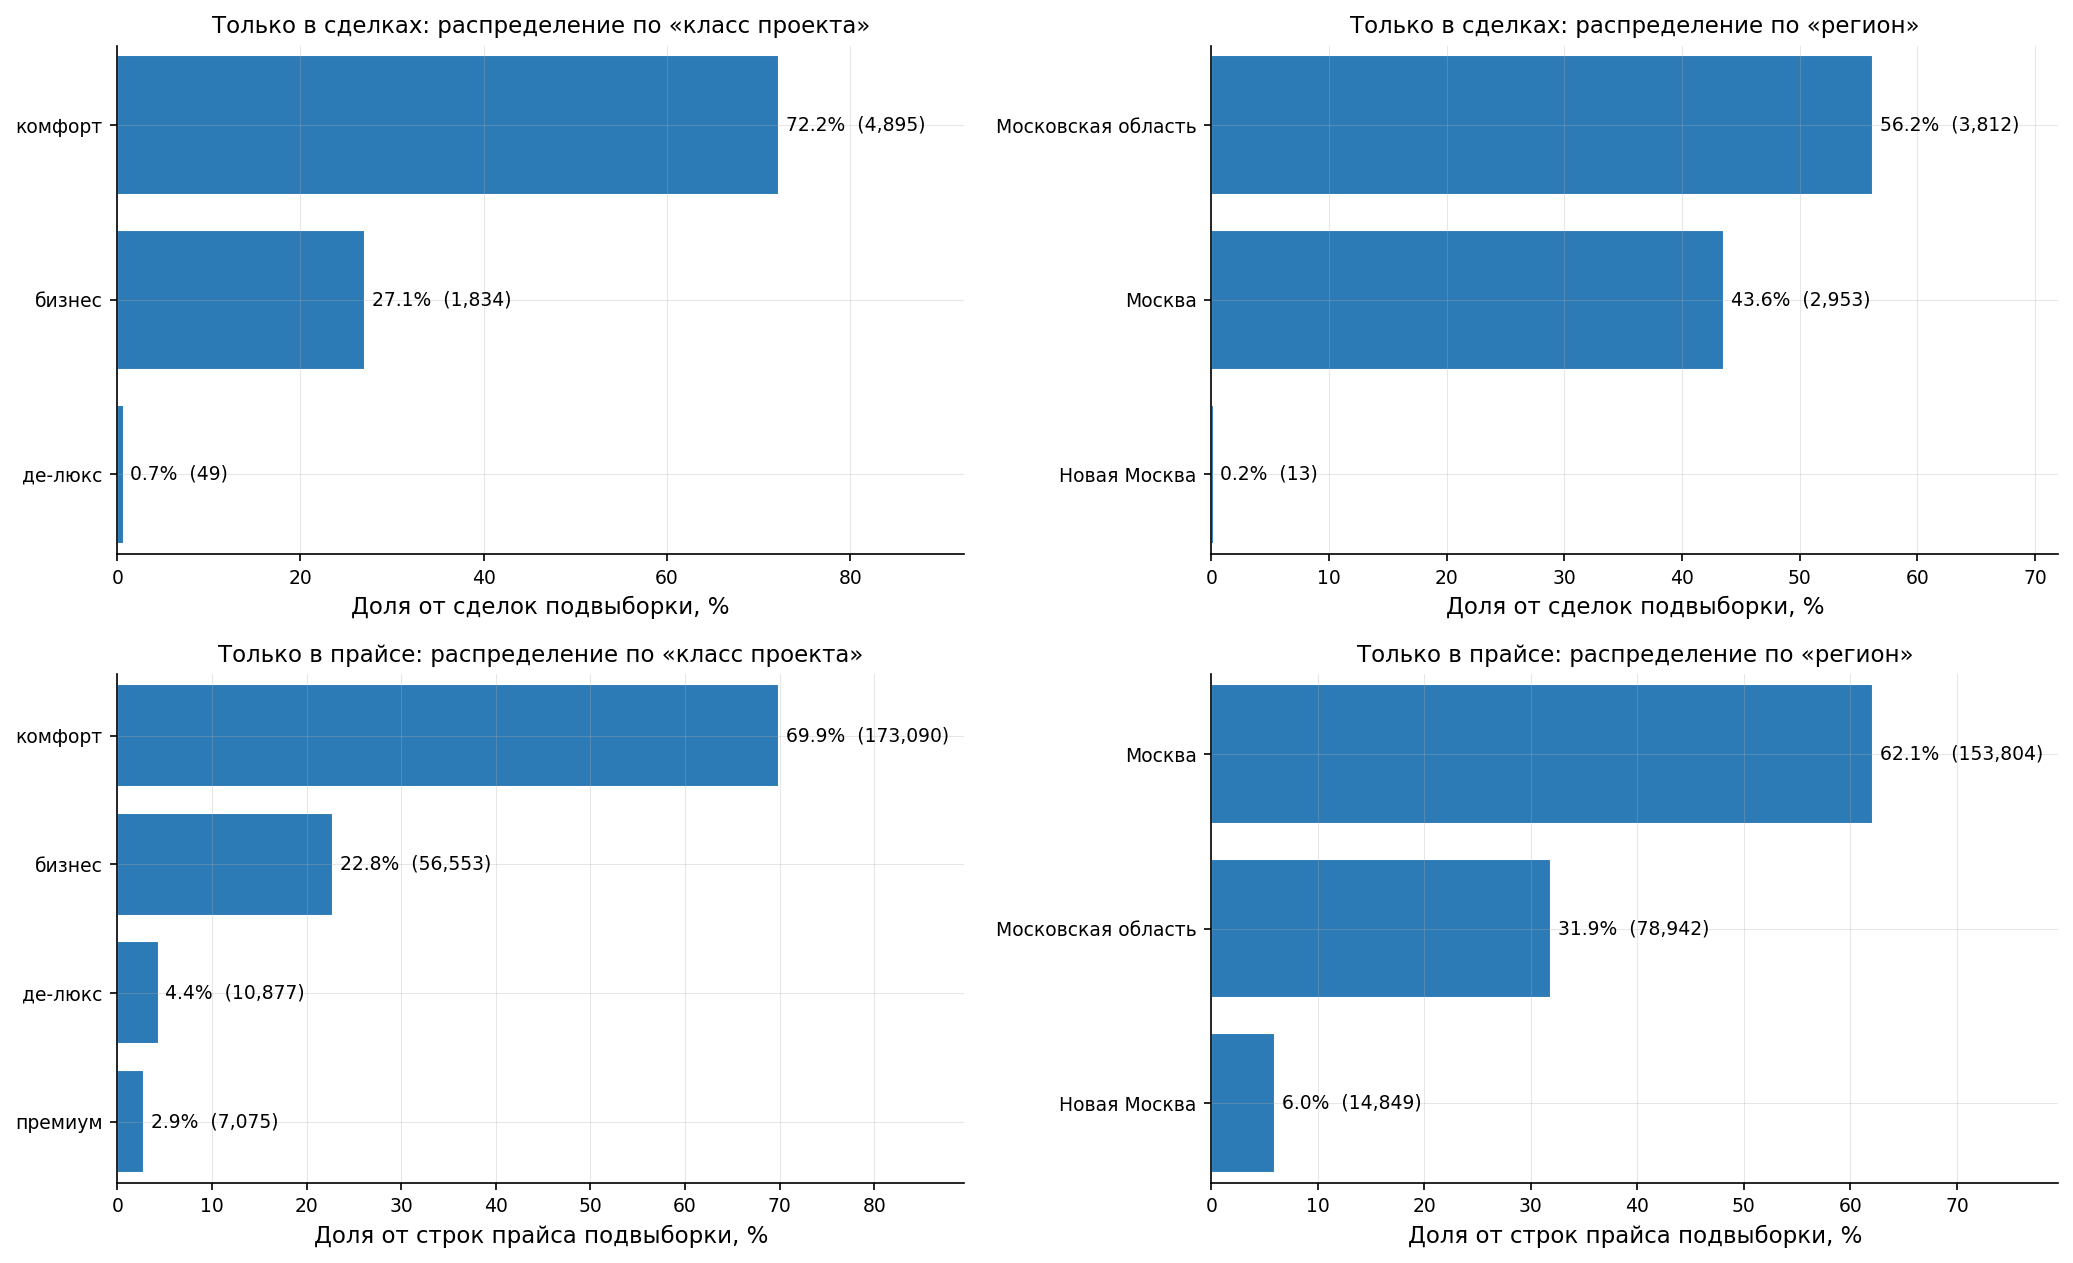

In [15]:
# --- Проекты-«сироты»: распределение по классу и региону (сетка 2×2) ---
# Доля = от числа строк ВНУТРИ соответствующей подвыборки сирот
# (для "только в сделках" — от их сделок; для "только в прайсе" — от их строк прайса).
import matplotlib.pyplot as plt

# (таблица, ключ-серия, набор id, рус.имя, англ.имя, заголовок группы, единица знаменателя)
_specs = [
    (deals,     deals_pid, only_deals, "Класс проекта", "project_class", "Только в сделках", "сделок"),
    (deals,     deals_pid, only_deals, "Регион",        "region",        "Только в сделках", "сделок"),
    (price_all, price_pid, only_price, "Класс проекта", "project_class", "Только в прайсе",  "строк прайса"),
    (price_all, price_pid, only_price, "Регион",        "region",        "Только в прайсе",  "строк прайса"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (df, pid, ids, ru, en, grp, unit) in zip(axes.ravel(), _specs):
    col = _col(df, ru, en)
    vc  = df.loc[pid.isin(ids), col].value_counts().sort_values()   # по возрастанию -> крупные сверху
    total = vc.sum()
    share = 100 * vc / total

    ax.barh(share.index.astype(str), share.values, color=C1, edgecolor="white")
    ax.set_title(f"{grp}: распределение по «{ru.lower()}»", fontsize=11)
    ax.set_xlabel(f"Доля от {unit} подвыборки, %")
    ax.set_xlim(0, float(share.max()) * 1.28)
    ax.margins(y=0.02)
    for y, (p, n) in enumerate(zip(share.values, vc.values)):
        ax.text(p + share.max() * 0.01, y, f"{p:.1f}%  ({n:,})", va="center", fontsize=9)

fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIG_DIR / "fig03_orphan_class_region.png", bbox_inches="tight")
plt.show()
